In [19]:
# Cell 1 - import wing-x
import pandas as pd
import numpy as np

# 1. SETUP & LOAD
METRO_PATH = "gs://agntworks-data-dev/wheelsup/processed/wingx/lj_smid_us_revenue_clean_24_25_metro.parquet"
print("🚀 Loading and processing 230-pair market audit...")
df = pd.read_parquet(METRO_PATH)

# 2. STANDARDIZE & FILTER
df['FlightDate_ET'] = pd.to_datetime(df['FlightDate_ET'])
df = df.rename(columns={'FromCluster': 'FromMetro', 'ToCluster': 'ToMetro'})

# --- CRITICAL FIX: Filter FIRST, then define corridor on the clean data ---
mask = (
    (df['aircraft_segment'] == 'Super Midsize Jet') & 
    (df['FromMetro'] != 'OTHER_METRO') & 
    (df['ToMetro'] != 'OTHER_METRO') & 
    (df['FromMetro'] != df['ToMetro']) & # This eliminates Intra-Metro
    (df['Hours'] >= 2.5)
)

# Create smid_lh as a clean, independent copy
smid_lh = df[mask].copy()

# Now define the corridor only for the legitimate inter-metro pairs
smid_lh['corridor'] = smid_lh['FromMetro'] + " -> " + smid_lh['ToMetro']

# 3. WUP PRESENCE DEFINITION
wup_mask = ((smid_lh['Operator'].str.contains('Wheels Up', case=False, na=False)) | 
            (smid_lh['Operator'] == 'Mountain Aviation'))
smid_lh['is_wup'] = wup_mask

# 4. BI-DIRECTIONAL AGGREGATION
def make_pair_key(row):
    return " <-> ".join(sorted([row['FromMetro'], row['ToMetro']]))

smid_lh['pair_key'] = smid_lh.apply(make_pair_key, axis=1)

# Aggregation logic
pair_analysis = smid_lh.groupby('pair_key').agg(
    total_pair_missions=('pair_key', 'size'),
    total_wup_missions=('is_wup', 'sum'),
    avg_hours_combined=('Hours', 'mean')
).reset_index()

def get_splits(group):
    counts = group['corridor'].value_counts()
    hrs = group.groupby('corridor')['Hours'].mean()
    wup = group.groupby('corridor')['is_wup'].sum()
    total = group.groupby('corridor').size()
    return pd.Series({
        'mission_split': " | ".join(counts.astype(str)),
        'hours_split': " | ".join([f"{h:.2f}" for h in hrs]),
        'share_split': " | ".join([f"{(w/t)*100:.1f}%" for w, t in zip(wup, total)])
    })

# 5. VALIDATION & OUTPUT
splits = smid_lh.groupby('pair_key').apply(get_splits).reset_index()
pair_analysis = pair_analysis.merge(splits, on='pair_key').sort_values('total_pair_missions', ascending=False)

# Validation check to ensure it's clean
intra_metro_count = smid_lh[smid_lh['FromMetro'] == smid_lh['ToMetro']].shape[0]
print(f"✅ Market Audit Complete.")
print(f"1. Total Inter-Metro Missions: {len(smid_lh):,}")
print(f"2. Unique Directional Corridors: {smid_lh['corridor'].nunique()}")
print(f"3. Intra-Metro (Same City) Missions: {intra_metro_count}")

display(pair_analysis.head(10))

🚀 Loading and processing 230-pair market audit...
✅ Market Audit Complete.
1. Total Inter-Metro Missions: 211,133
2. Unique Directional Corridors: 447
3. Intra-Metro (Same City) Missions: 0


/var/tmp/ipykernel_17277/2576852232.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  splits = smid_lh.groupby('pair_key').apply(get_splits).reset_index()


,pair_key,total_pair_missions,total_wup_missions,avg_hours_combined,mission_split,hours_split,share_split
200,New York City <-> South Florida,13756,130,2.728246,8054 | 5702,2.76 | 2.68,1.2% | 0.6%
130,Denver <-> New York City,8041,460,3.821391,4032 | 4009,3.50 | 4.14,5.9% | 5.6%
57,Boston <-> South Florida,7900,257,2.895832,4268 | 3632,3.02 | 2.76,3.5% | 2.9%
92,Chicago <-> South Florida,7087,121,2.736125,4212 | 2875,2.67 | 2.78,1.6% | 1.8%
137,Denver <-> South Florida,6377,478,3.935630,3269 | 3108,3.64 | 4.25,7.3% | 7.7%
166,LA Basin <-> New York City,5939,104,4.962665,3066 | 2873,4.60 | 5.35,2.0% | 1.5%
82,Chicago <-> LA Basin,5113,172,3.561338,2596 | 2517,3.83 | 3.28,3.2% | 3.6%
173,LA Basin <-> South Florida,4716,159,4.647834,2424 | 2292,4.21 | 5.11,3.2% | 3.5%
113,Dallas <-> LA Basin,4637,72,2.802512,3305 | 1332,2.85 | 2.68,1.8% | 1.1%
116,Dallas <-> New York City,4351,90,3.062016,2289 | 2062,2.87 | 3.23,1.8% | 2.3%


In [20]:
# -----------------------------------------------------------------------------------------
# CELL 2: DIRECTIONAL SEASONAL DISCOVERY — SMID
# -----------------------------------------------------------------------------------------

from sklearn.cluster import KMeans

# 1. Build monthly corridor fingerprint
seasonal_counts = (
    smid_lh
    .groupby(["corridor", "month"])
    .size()
    .unstack(fill_value=0)
)

# Ensure all month columns exist
seasonal_counts = seasonal_counts.reindex(columns=range(1, 13), fill_value=0)

# 2. Filter for statistical signal
MIN_MISSIONS = 30

annual_missions = seasonal_counts.sum(axis=1)
relevant_corridors = annual_missions > MIN_MISSIONS

seasonal_counts_relevant = seasonal_counts.loc[relevant_corridors].copy()

# 3. Normalize to monthly density
# This isolates the seasonal shape of each corridor.
monthly_density = seasonal_counts_relevant.div(
    seasonal_counts_relevant.sum(axis=1),
    axis=0
)

# 4. Create seasonality index
# 1.00x = normal monthly demand
# >1.00x = above-normal seasonal intensity
# <1.00x = below-normal seasonal intensity
seasonality_index = monthly_density / (1 / 12)

# 5. K-Means clustering
km = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=50
)

cluster_ids = km.fit_predict(monthly_density)

# 6. Build audit/output dataframe
X_discovery = monthly_density.copy()
X_discovery["cluster_id"] = cluster_ids
X_discovery["annual_missions"] = annual_missions.loc[relevant_corridors] / 2

for m in range(1, 13):
    X_discovery[f"seasonality_index_m{m}"] = seasonality_index[m]

# 7. Display cluster centers — monthly density
cluster_centers_density = (
    X_discovery
    .groupby("cluster_id")[list(range(1, 13))]
    .mean()
    .reindex(columns=range(1, 13))
)

print(f"✅ Processed {len(X_discovery)} SMID corridors into 4 seasonal demand regimes.")
print("\n📈 MONTHLY DENSITY BY CLUSTER:")
display(
    cluster_centers_density
    .style
    .background_gradient(axis=1, cmap="YlOrRd")
    .format("{:.1%}")
)

# 8. Display cluster centers — seasonality index
seasonality_cols = [f"seasonality_index_m{m}" for m in range(1, 13)]

cluster_centers_index = (
    X_discovery
    .groupby("cluster_id")[seasonality_cols]
    .mean()
)

cluster_centers_index.columns = range(1, 13)

print("\n📈 SEASONALITY INDEX BY CLUSTER:")
display(
    cluster_centers_index
    .style
    .background_gradient(axis=1, cmap="YlOrRd")
    .format("{:.2f}x")
)

✅ Processed 289 SMID corridors into 4 seasonal demand regimes.

📈 MONTHLY DENSITY BY CLUSTER:


month,1,2,3,4,5,6,7,8,9,10,11,12
cluster_id,,,,,,,,,,,,
0,12.7%,11.9%,12.1%,10.6%,8.8%,4.3%,3.5%,3.7%,4.5%,6.7%,10.2%,11.0%
1,4.1%,4.1%,5.2%,6.6%,9.1%,11.3%,12.4%,12.6%,10.7%,10.5%,7.0%,6.3%
2,7.1%,7.6%,7.9%,8.7%,9.4%,7.9%,6.9%,7.2%,8.7%,10.6%,9.6%,8.5%
3,9.2%,9.3%,10.0%,4.9%,5.4%,8.8%,11.5%,10.8%,8.4%,6.6%,5.1%,9.9%



📈 SEASONALITY INDEX BY CLUSTER:


,1,2,3,4,5,6,7,8,9,10,11,12
cluster_id,,,,,,,,,,,,
0,1.52x,1.43x,1.45x,1.27x,1.05x,0.51x,0.42x,0.45x,0.54x,0.80x,1.23x,1.32x
1,0.49x,0.50x,0.63x,0.80x,1.09x,1.36x,1.49x,1.51x,1.29x,1.26x,0.84x,0.75x
2,0.85x,0.91x,0.95x,1.04x,1.13x,0.94x,0.83x,0.86x,1.04x,1.27x,1.16x,1.02x
3,1.11x,1.11x,1.20x,0.59x,0.65x,1.06x,1.38x,1.30x,1.00x,0.80x,0.62x,1.19x


In [21]:
# -----------------------------------------------------------------------------------------
# CELL 3.5: LABELED SEASONALITY AUDIT (SYNCED)
# -----------------------------------------------------------------------------------------

# 1. Re-define labels locally to force a sync (Matches your Cell 4 logic)
final_labels = {
    0: "winter-spring-peak",   
    1: "summer-peak",        
    2: "multi-peak-directional", 
    3: "core-utilization"
}

# 2. Calculate centers from X_discovery
labeled_centers = X_discovery.groupby("cluster_id")[list(range(1, 13))].mean()

# 3. Apply labels to the index (Prepend ID for clarity)
labeled_centers.index = [f"{i}: {final_labels.get(i, 'Unknown')}" for i in labeled_centers.index]

print("🎯 FINAL SMID ARCHETYPE HEATMAP (Monthly Density %):")
display(
    labeled_centers.style.background_gradient(axis=1, cmap="YlOrRd")
    .format("{:.1%}")
)

# 4. Toggle Logic Calculation
# May is index 5, June is index 6
summer_jump = labeled_centers[6] - labeled_centers[5]
top_toggle = summer_jump.idxmax()

print(f"\n💡 The strongest June 'Toggle' candidate is: {top_toggle}")
print(f"📈 Momentum: +{summer_jump.max():.1%} absolute density increase MoM.")

🎯 FINAL SMID ARCHETYPE HEATMAP (Monthly Density %):


month,1,2,3,4,5,6,7,8,9,10,11,12
0: winter-spring-peak,12.7%,11.9%,12.1%,10.6%,8.8%,4.3%,3.5%,3.7%,4.5%,6.7%,10.2%,11.0%
1: summer-peak,4.1%,4.1%,5.2%,6.6%,9.1%,11.3%,12.4%,12.6%,10.7%,10.5%,7.0%,6.3%
2: multi-peak-directional,7.1%,7.6%,7.9%,8.7%,9.4%,7.9%,6.9%,7.2%,8.7%,10.6%,9.6%,8.5%
3: core-utilization,9.2%,9.3%,10.0%,4.9%,5.4%,8.8%,11.5%,10.8%,8.4%,6.6%,5.1%,9.9%



💡 The strongest June 'Toggle' candidate is: 3: core-utilization
📈 Momentum: +3.4% absolute density increase MoM.


In [22]:
# -----------------------------------------------------------------------------------------
# FINAL VALIDATION: SMID UNIVERSE & VOLUME DISTRIBUTION
# -----------------------------------------------------------------------------------------

# 1. Labels strictly aligned with Cell 3.5 Heatmap
final_labels_smid = {
    0: "winter-spring-peak",   
    1: "summer-peak",        
    2: "multi-peak-directional", 
    3: "core-utilization"
}

# 2. Metadata & Volume Calculations
total_corridors = len(X_discovery)
total_flights = X_discovery['annual_missions'].sum()

# Grouping by mapped labels for volume analysis
stats = X_discovery.groupby('cluster_id').agg({'annual_missions': ['count', 'sum']})
stats.index = stats.index.map(final_labels_smid)
stats.columns = ['corridor_count', 'flight_volume']
stats['volume_pct'] = (stats['flight_volume'] / total_flights) * 100

# 3. Intra-Metro Check
intra_metro_issues = [c for c in X_discovery.index if c.split(' -> ')[0] == c.split(' -> ')[1]]

# 4. Validation Output
print("📊 --- SMID CLUSTER UNIVERSE SUMMARY ---")
print(f"📌 Filtering Criteria Applied:")
print(f"   - Segment      : Super Midsize Jet")
print(f"   - Min Leg Time : >= 2.5 Hours")
print(f"   - Relevance    : > {MIN_MISSIONS} missions total (2-yr)")
print(f"   - Logic        : Inter-Metro Only (No Same-City)")

print(f"\n✅ Total Inter-Metro Corridors : {total_corridors}")
print(f"✅ Total Annual Flight Volume  : {total_flights:,.0f} (Annualized /2)")

print("\n📍 SMID ARCHETYPE BREAKDOWN (Volume & Count):")
print(f"{'Archetype':<25} | {'Corridors':<10} | {'Flights':<12} | {'Volume %'}")
print("-" * 65)
for label, row in stats.sort_values('flight_volume', ascending=False).iterrows():
    print(f"{label:<25} | {int(row['corridor_count']):<10} | {int(row['flight_volume']):<12,} | {row['volume_pct']:.1f}%")

print("\n🛡️ --- SAFETY CHECKS ---")
if not intra_metro_issues:
    print(f"✅ Final Validation Passed: 0 intra-metro corridors found.")
else:
    print(f"❌ Final Validation Failed: Found {len(intra_metro_issues)} intra-metro records!")

📊 --- SMID CLUSTER UNIVERSE SUMMARY ---
📌 Filtering Criteria Applied:
   - Segment      : Super Midsize Jet
   - Min Leg Time : >= 2.5 Hours
   - Relevance    : > 30 missions total (2-yr)
   - Logic        : Inter-Metro Only (No Same-City)

✅ Total Inter-Metro Corridors : 289
✅ Total Annual Flight Volume  : 104,992 (Annualized /2)

📍 SMID ARCHETYPE BREAKDOWN (Volume & Count):
Archetype                 | Corridors  | Flights      | Volume %
-----------------------------------------------------------------
multi-peak-directional    | 117        | 44,008       | 41.9%
winter-spring-peak        | 61         | 28,404       | 27.1%
core-utilization          | 41         | 18,716       | 17.8%
summer-peak               | 70         | 13,863       | 13.2%

🛡️ --- SAFETY CHECKS ---
✅ Final Validation Passed: 0 intra-metro corridors found.


In [23]:
# Check current columns and a sample row
print(f"Columns: {X_discovery.columns.tolist()}")
display(X_discovery.head(1))

Columns: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 'cluster_id', 'annual_missions', 'seasonality_index_m1', 'seasonality_index_m2', 'seasonality_index_m3', 'seasonality_index_m4', 'seasonality_index_m5', 'seasonality_index_m6', 'seasonality_index_m7', 'seasonality_index_m8', 'seasonality_index_m9', 'seasonality_index_m10', 'seasonality_index_m11', 'seasonality_index_m12']


month,1,2,3,4,5,6,7,8,9,10,...,seasonality_index_m3,seasonality_index_m4,seasonality_index_m5,seasonality_index_m6,seasonality_index_m7,seasonality_index_m8,seasonality_index_m9,seasonality_index_m10,seasonality_index_m11,seasonality_index_m12
corridor,,,,,,,,,,,,,,,,,,,,,
Atlanta -> Bay Area,0.028103,0.065574,0.058548,0.135831,0.074941,0.081967,0.0726,0.119438,0.065574,0.135831,...,0.702576,1.629977,0.899297,0.983607,0.871194,1.433255,0.786885,1.629977,1.264637,0.674473


In [24]:
# -----------------------------------------------------------------------------------------
# SMID INTENSITY SLAB DATASET — corridor | month | density_pct | cluster_label | slab | intensity
# Dependencies: Cell 1 (smid_lh) + Cell 2 (X_discovery)
# -----------------------------------------------------------------------------------------

MONTH_NAMES = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}

final_labels_smid = {0:"winter-spring-peak", 1:"summer-peak",
                     2:"multi-peak-directional", 3:"core-utilization"}

# Build long format from X_discovery
base = X_discovery[list(range(1,13)) + ["cluster_id", "annual_missions"]].copy().reset_index()
for m in range(1, 13):
    base[m] = (base[m] * 100).round(2)
base = base.rename(columns=MONTH_NAMES)
base["cluster_label"] = base["cluster_id"].map(final_labels_smid)

slab_df = base.melt(
    id_vars=["corridor", "cluster_label"],
    value_vars=list(MONTH_NAMES.values()),
    var_name="month", value_name="density_pct"
)

# Slab + intensity
bins   = [0, 4, 6, 9, 12, 15, float("inf")]
labels = ["< 4%", "4%-6%", "6%-9%", "9%-12%", "12%-15%", "> 15%"]
intensity_map = {"< 4%":0, "4%-6%":1, "6%-9%":2, "9%-12%":3, "12%-15%":4, "> 15%":5}
slab_df["slab"]      = pd.cut(slab_df["density_pct"], bins=bins, labels=labels, right=False)
slab_df["intensity"] = slab_df["slab"].map(intensity_map)

slab_df = (slab_df[["corridor", "month", "density_pct", "cluster_label", "slab", "intensity"]]
           .sort_values(["cluster_label", "corridor", "month"]).reset_index(drop=True))

slab_df.to_csv("smid_kmeans_intensity_slab.csv", index=False)

print(f"✅ SMID slab dataset ready: {len(slab_df):,} rows × {len(slab_df.columns)} columns")
print(f"📁 Exported to: smid_kmeans_intensity_slab.csv")
display(slab_df.head(24))

✅ SMID slab dataset ready: 3,468 rows × 6 columns
📁 Exported to: smid_kmeans_intensity_slab.csv


,corridor,month,density_pct,cluster_label,slab,intensity
0,Atlanta -> Denver,Apr,6.36,core-utilization,6%-9%,2
1,Atlanta -> Denver,Aug,8.74,core-utilization,6%-9%,2
2,Atlanta -> Denver,Dec,10.42,core-utilization,9%-12%,3
3,Atlanta -> Denver,Feb,9.93,core-utilization,9%-12%,3
4,Atlanta -> Denver,Jan,7.90,core-utilization,6%-9%,2
5,Atlanta -> Denver,Jul,12.24,core-utilization,12%-15%,4
6,Atlanta -> Denver,Jun,10.14,core-utilization,9%-12%,3
7,Atlanta -> Denver,Mar,8.74,core-utilization,6%-9%,2
8,Atlanta -> Denver,May,5.45,core-utilization,4%-6%,1
9,Atlanta -> Denver,Nov,4.83,core-utilization,4%-6%,1


In [25]:
lj_df   = pd.read_csv("lj_kmeans_intensity_slab.csv")
smid_df = pd.read_csv("smid_kmeans_intensity_slab.csv")

lj_df["AircraftType"]   = "Light Jet"
smid_df["AircraftType"] = "Super Midsize Jet"

combined = pd.concat([lj_df, smid_df], ignore_index=True)

# Final column order
combined = combined[["AircraftType", "corridor", "month", "density_pct",
                      "cluster_label", "slab", "intensity"]]

combined.to_csv("lj_smid_kmeans_intensity_slab_combined.csv", index=False)

print(f"✅ Combined dataset: {len(combined):,} rows")
print(f"   LJ rows  : {len(lj_df):,}")
print(f"   SMID rows: {len(smid_df):,}")
display(combined.head(10))


✅ Combined dataset: 7,788 rows
   LJ rows  : 4,320
   SMID rows: 3,468


,AircraftType,corridor,month,density_pct,cluster_label,slab,intensity
0,Light Jet,Atlanta -> Dallas,Jan,9.34,winter-spring-peak,9%-12%,3
1,Light Jet,Atlanta -> Dallas,Feb,7.45,winter-spring-peak,6%-9%,2
2,Light Jet,Atlanta -> Dallas,Mar,9.20,winter-spring-peak,9%-12%,3
3,Light Jet,Atlanta -> Dallas,Apr,12.26,winter-spring-peak,12%-15%,4
4,Light Jet,Atlanta -> Dallas,May,7.74,winter-spring-peak,6%-9%,2
5,Light Jet,Atlanta -> Dallas,Jun,6.42,winter-spring-peak,6%-9%,2
6,Light Jet,Atlanta -> Dallas,Jul,4.53,winter-spring-peak,4%-6%,1
7,Light Jet,Atlanta -> Dallas,Aug,4.67,winter-spring-peak,4%-6%,1
8,Light Jet,Atlanta -> Dallas,Sep,9.20,winter-spring-peak,9%-12%,3
9,Light Jet,Atlanta -> Dallas,Oct,8.76,winter-spring-peak,6%-9%,2


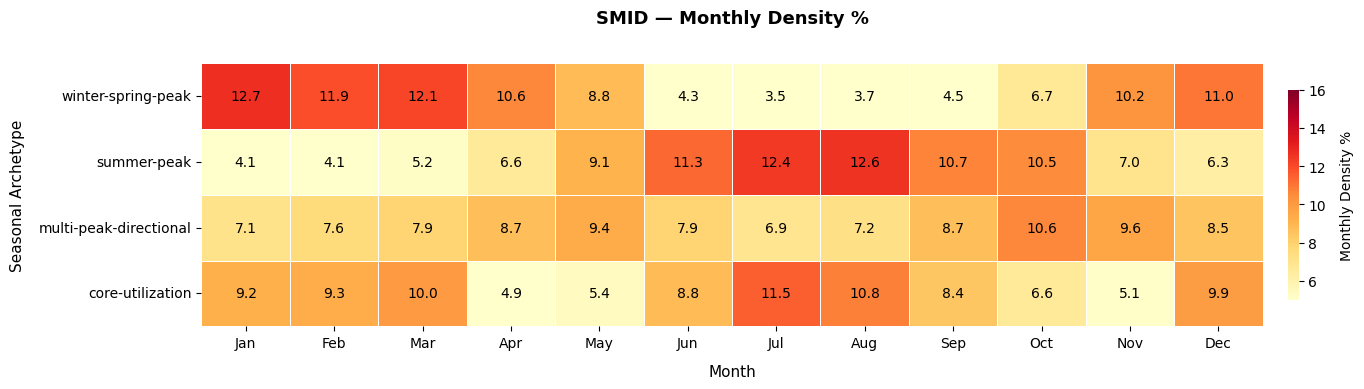

✅ Saved → smid_monthly_density_heatmap.png


In [33]:
# -----------------------------------------------------------------------------------------
# SMID MONTHLY DENSITY HEATMAP — saved as image
# Dependencies: Cell 2 (X_discovery)
# -----------------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ARCHETYPE_ORDER = [
    "winter-spring-peak",    # cluster_id 0
    "summer-peak",           # cluster_id 1
    "multi-peak-directional",# cluster_id 2
    "core-utilization"       # cluster_id 3
]

final_labels_smid = {0:"winter-spring-peak", 1:"summer-peak",
                     2:"multi-peak-directional", 3:"core-utilization"}

# Build cluster-center monthly density pivot
density_df = X_discovery[list(range(1,13)) + ["cluster_id"]].copy()
density_df["cluster_label"] = density_df["cluster_id"].map(final_labels_smid)
density_df = density_df.rename(columns={m: mn for m, mn in enumerate(MONTHS, 1)})

pivot = (density_df.groupby("cluster_label")[MONTHS]
                   .mean()
                   .mul(100)
                   .round(1)
                   .reindex(index=ARCHETYPE_ORDER))

# Toggle insight
summer_jump = pivot["Jun"] - pivot["May"]
top_toggle  = summer_jump.idxmax()

# --- Plot ---
fig, ax = plt.subplots(figsize=(15, 4))

sns.heatmap(
    pivot, ax=ax,
    cmap="YlOrRd", vmin=5, vmax=16,
    annot=True, fmt=".1f",
    annot_kws={"size": 10, "color": "black"},
    linewidths=0.6, linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.02}
)

ax.set_title(
    f"SMID — Monthly Density %\n",
    fontsize=13, fontweight="bold", pad=14
)
ax.set_xlabel("Month", fontsize=11, labelpad=10)
ax.set_ylabel("Seasonal Archetype", fontsize=11, labelpad=10)
ax.tick_params(axis="x", labelsize=10, rotation=0)
ax.tick_params(axis="y", labelsize=10, rotation=0)

ax.collections[0].colorbar.set_label("Monthly Density %", fontsize=10, labelpad=10)

plt.tight_layout()
OUT = "smid_monthly_density_heatmap.png"
plt.savefig(OUT, dpi=180, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {OUT}")

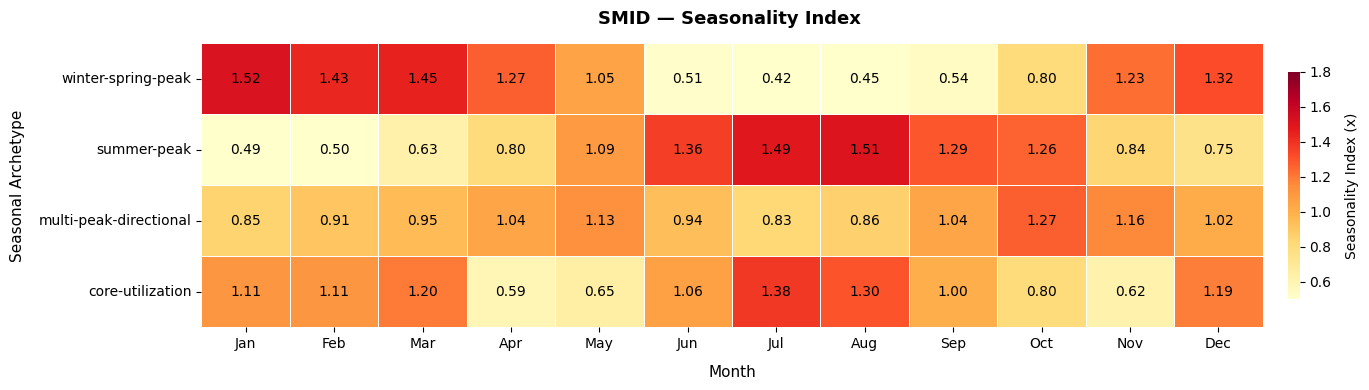

✅ Saved → smid_seasonality_index_heatmap.png


In [34]:
# -----------------------------------------------------------------------------------------
# SMID SEASONALITY INDEX HEATMAP — saved as image
# Dependencies: Cell 2 (X_discovery)
# -----------------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ARCHETYPE_ORDER = [
    "winter-spring-peak",    # cluster_id 0
    "summer-peak",           # cluster_id 1
    "multi-peak-directional",# cluster_id 2
    "core-utilization"       # cluster_id 3
]

final_labels_smid = {0:"winter-spring-peak", 1:"summer-peak",
                     2:"multi-peak-directional", 3:"core-utilization"}

# Build cluster-center seasonality index pivot
si_col_map = {f"seasonality_index_m{m}": mn for m, mn in enumerate(MONTHS, 1)}
si_df = X_discovery[[f"seasonality_index_m{m}" for m in range(1,13)] + ["cluster_id"]].copy()
si_df["cluster_label"] = si_df["cluster_id"].map(final_labels_smid)
si_df = si_df.rename(columns=si_col_map)

pivot = (si_df.groupby("cluster_label")[MONTHS]
              .mean()
              .round(2)
              .reindex(index=ARCHETYPE_ORDER))

# --- Plot ---
fig, ax = plt.subplots(figsize=(15, 4))

sns.heatmap(
    pivot, ax=ax,
    cmap="YlOrRd", vmin=0.5, vmax=1.8,
    annot=True, fmt=".2f",
    annot_kws={"size": 10, "color": "black"},
    linewidths=0.6, linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.02}
)

ax.set_title("SMID — Seasonality Index ",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Month", fontsize=11, labelpad=10)
ax.set_ylabel("Seasonal Archetype", fontsize=11, labelpad=10)
ax.tick_params(axis="x", labelsize=10, rotation=0)
ax.tick_params(axis="y", labelsize=10, rotation=0)

ax.collections[0].colorbar.set_label("Seasonality Index (x)", fontsize=10, labelpad=10)

plt.tight_layout()
OUT = "smid_seasonality_index_heatmap.png"
plt.savefig(OUT, dpi=180, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {OUT}")

# TOP 12

In [2]:
# -----------------------------------------------------------------------------------------
# SMID CELL 12: COMPREHENSIVE DATASET
# cluster_label | corridor | month | density_pct | seasonality_index | slab | intensity
# Merges smid_corridor_seasonal_dataset.csv + smid_kmeans_intensity_slab.csv
# Output: smid_comprehensive.csv
# -----------------------------------------------------------------------------------------
import pandas as pd

MONTH_ORDER     = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ARCHETYPE_ORDER = ['winter-spring-peak','summer-peak','core-utilization','multi-peak-directional']

# Build smid_corridor_seasonal_dataset.csv if not already present
src = pd.read_csv('smid_kmeans_intensity_slab.csv')
src['seasonality_index'] = (src['density_pct'] * 12 / 100).round(4)
seasonal = src[['corridor','month','density_pct','seasonality_index','cluster_label']]
seasonal.to_csv('smid_corridor_seasonal_dataset.csv', index=False)

base = pd.read_csv('smid_corridor_seasonal_dataset.csv')
slab = pd.read_csv('smid_kmeans_intensity_slab.csv')[['corridor','month','slab','intensity']]

comp = base.merge(slab, on=['corridor','month'], how='left')
comp['month']         = pd.Categorical(comp['month'],         categories=MONTH_ORDER,     ordered=True)
comp['cluster_label'] = pd.Categorical(comp['cluster_label'], categories=ARCHETYPE_ORDER, ordered=True)
comp = (comp[['cluster_label','corridor','month','density_pct','seasonality_index','slab','intensity']]
            .sort_values(['cluster_label','corridor','month'])
            .reset_index(drop=True))

comp.to_csv('smid_comprehensive.csv', index=False)
print(f'Done: {len(comp):,} rows x {len(comp.columns)} columns -> smid_comprehensive.csv')
display(comp.head(12))

Done: 3,468 rows x 7 columns -> smid_comprehensive.csv


,cluster_label,corridor,month,density_pct,seasonality_index,slab,intensity
0,winter-spring-peak,Atlanta -> Dallas,Jan,9.30,1.1160,9%-12%,3
1,winter-spring-peak,Atlanta -> Dallas,Feb,11.63,1.3956,9%-12%,3
2,winter-spring-peak,Atlanta -> Dallas,Mar,9.30,1.1160,9%-12%,3
3,winter-spring-peak,Atlanta -> Dallas,Apr,18.60,2.2320,> 15%,5
4,winter-spring-peak,Atlanta -> Dallas,May,20.93,2.5116,> 15%,5
5,winter-spring-peak,Atlanta -> Dallas,Jun,0.00,0.0000,< 4%,0
6,winter-spring-peak,Atlanta -> Dallas,Jul,2.33,0.2796,< 4%,0
7,winter-spring-peak,Atlanta -> Dallas,Aug,2.33,0.2796,< 4%,0
8,winter-spring-peak,Atlanta -> Dallas,Sep,2.33,0.2796,< 4%,0
9,winter-spring-peak,Atlanta -> Dallas,Oct,4.65,0.5580,4%-6%,1


Done: 48 rows x 10 columns -> smid_top12_per_archetype.csv


,cluster_label,rank,corridor,peak_month,peak_density_pct,avg_density_pct,avg_seasonality_idx,months_above_avg,peak_slab,peak_intensity
0,winter-spring-peak,1,DMV -> South Florida,Jan,27.60,8.33,1.0000,5,> 15%,5
1,winter-spring-peak,2,San Antonio -> Phoenix Valley,Feb,26.47,8.33,1.0000,5,> 15%,5
2,winter-spring-peak,3,Philadelphia -> North Florida,Jan,24.39,8.34,1.0003,4,> 15%,5
3,winter-spring-peak,4,North Florida -> Houston,Mar,24.14,8.33,0.9999,6,> 15%,5
4,winter-spring-peak,5,Atlanta -> San Antonio,Apr,23.16,8.33,1.0001,5,> 15%,5
5,winter-spring-peak,6,DMV -> St. Louis,Jan,22.45,8.33,0.9999,5,> 15%,5
6,winter-spring-peak,7,South Florida -> Houston,Mar,21.65,8.34,1.0002,5,> 15%,5
7,winter-spring-peak,8,Pittsburgh -> North Florida,Dec,21.43,8.33,1.0000,5,> 15%,5
8,winter-spring-peak,9,North Florida -> San Antonio,Jan,20.96,8.33,1.0001,6,> 15%,5
9,winter-spring-peak,10,Atlanta -> Dallas,May,20.93,8.33,1.0000,7,> 15%,5


/var/tmp/ipykernel_47210/3114077256.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


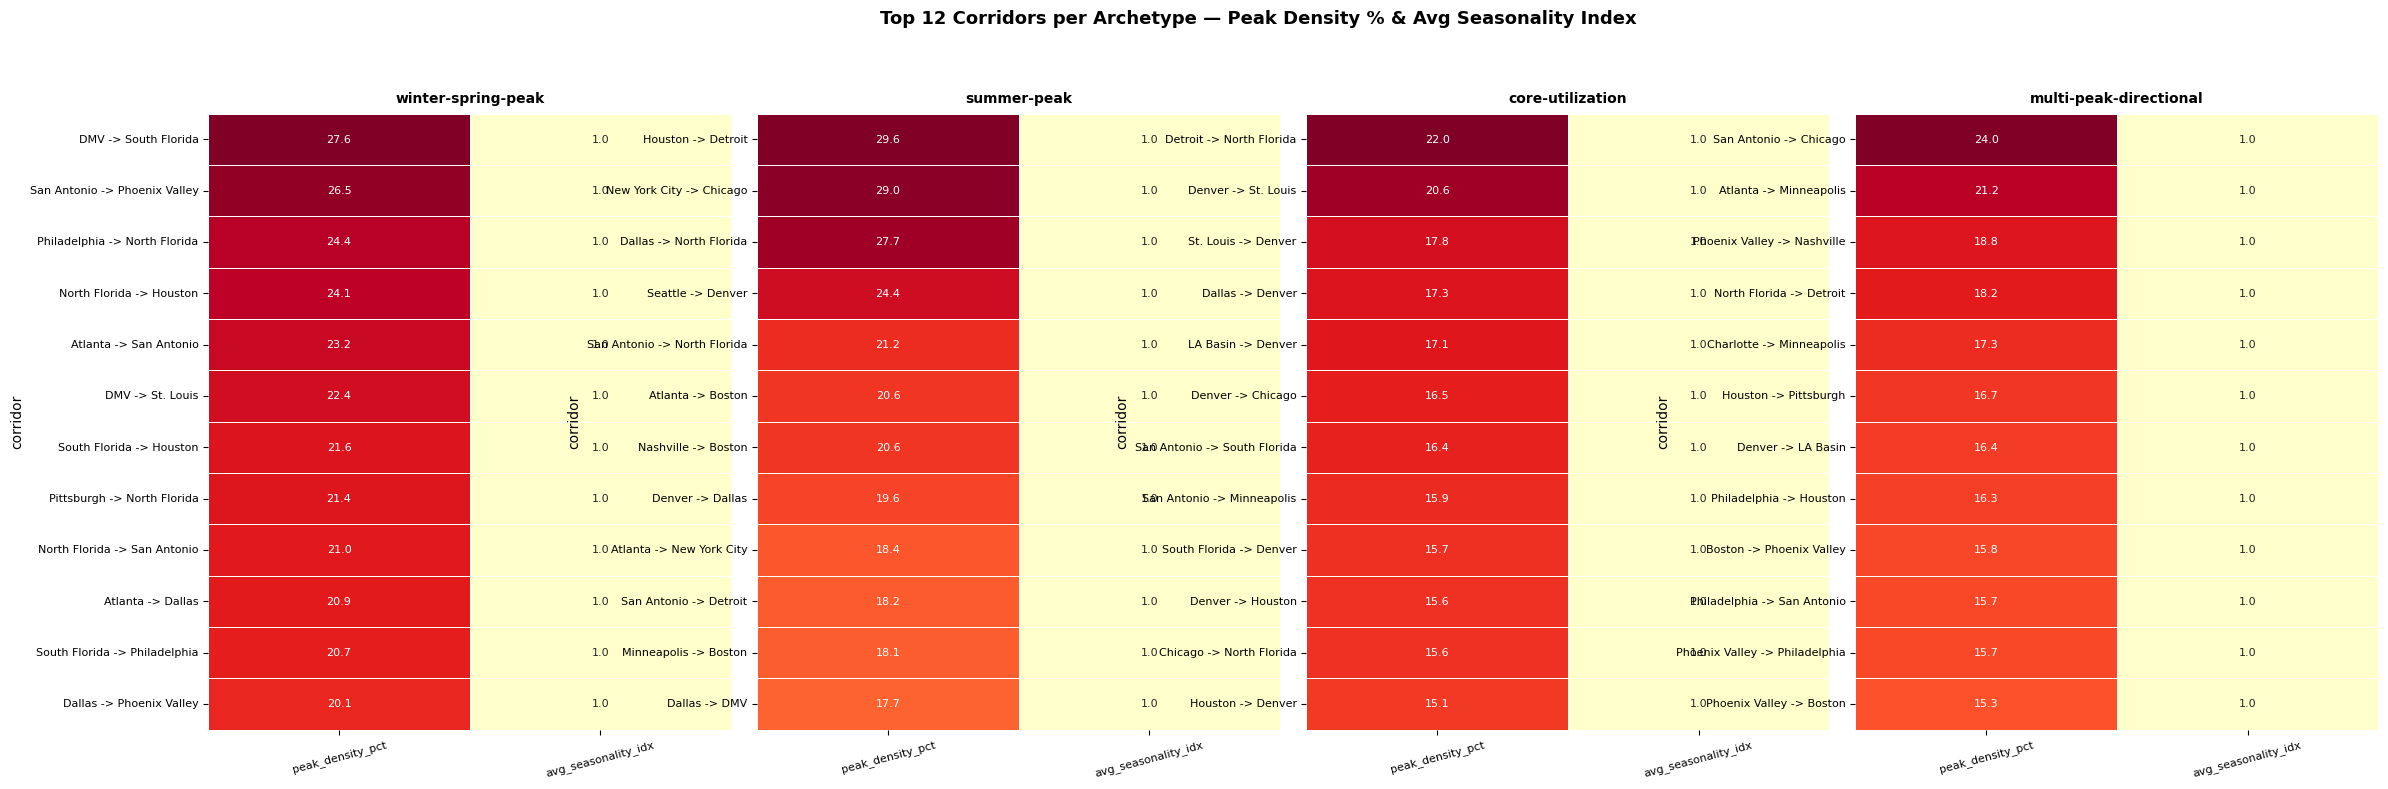

Saved -> smid_top12_heatmap.png


In [3]:
# -----------------------------------------------------------------------------------------
# SMID CELL 13: TOP 12 CORRIDORS PER ARCHETYPE
# Ranked by peak_density_pct within each cluster_label
# Reads: smid_comprehensive.csv
# Output: smid_top12_per_archetype.csv + smid_top12_heatmap.png
# -----------------------------------------------------------------------------------------
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

MONTH_ORDER     = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ARCHETYPE_ORDER = ['winter-spring-peak','summer-peak','core-utilization','multi-peak-directional']

comp = pd.read_csv('smid_comprehensive.csv')
comp['month']         = pd.Categorical(comp['month'],         categories=MONTH_ORDER,     ordered=True)
comp['cluster_label'] = pd.Categorical(comp['cluster_label'], categories=ARCHETYPE_ORDER, ordered=True)

# Corridor-level aggregation
def peak_month(g):
    return g.loc[g['density_pct'].idxmax(), 'month']

def peak_slab(g):
    return g.loc[g['intensity'].idxmax(), 'slab']

agg = (comp.groupby(['cluster_label','corridor'], observed=True)
           .apply(lambda g: pd.Series({
               'peak_density_pct'   : g['density_pct'].max(),
               'peak_month'         : peak_month(g),
               'avg_density_pct'    : g['density_pct'].mean().round(2),
               'avg_seasonality_idx': g['seasonality_index'].mean().round(4),
               'months_above_avg'   : int((g['density_pct'] > 100/12).sum()),
               'peak_intensity'     : int(g['intensity'].max()),
               'peak_slab'          : peak_slab(g),
           }), include_groups=False)
           .reset_index())

agg['rank'] = (agg.groupby('cluster_label', observed=True)['peak_density_pct']
                   .rank(method='first', ascending=False).astype(int))

top12 = (agg[agg['rank'] <= 12]
             .sort_values(['cluster_label','rank'])
             .reset_index(drop=True)
             [['cluster_label','rank','corridor','peak_month','peak_density_pct',
               'avg_density_pct','avg_seasonality_idx','months_above_avg','peak_slab','peak_intensity']])

top12['peak_density_pct'] = top12['peak_density_pct'].round(2)

top12.to_csv('smid_top12_per_archetype.csv', index=False)
print(f'Done: {len(top12)} rows x {len(top12.columns)} columns -> smid_top12_per_archetype.csv')
display(top12)

# Heatmap: peak_density_pct of top 12 per archetype
pivot = (top12.pivot(index='corridor', columns='cluster_label', values='peak_density_pct')
              .reindex(columns=ARCHETYPE_ORDER))

fig, axes = plt.subplots(1, 4, figsize=(28, 8), gridspec_kw={'wspace': 0.05})
for ax, arch in zip(axes, ARCHETYPE_ORDER):
    chunk = top12[top12['cluster_label'] == arch].set_index('corridor')[['peak_density_pct','avg_seasonality_idx']]
    sns.heatmap(
        chunk, ax=ax,
        cmap='YlOrRd', annot=True, fmt='.1f',
        annot_kws={'size': 8}, linewidths=0.5, linecolor='white',
        cbar=False
    )
    ax.set_title(arch, fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel('')
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=8, rotation=15)

plt.suptitle('Top 12 Corridors per Archetype — Peak Density % & Avg Seasonality Index',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('smid_top12_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> smid_top12_heatmap.png')